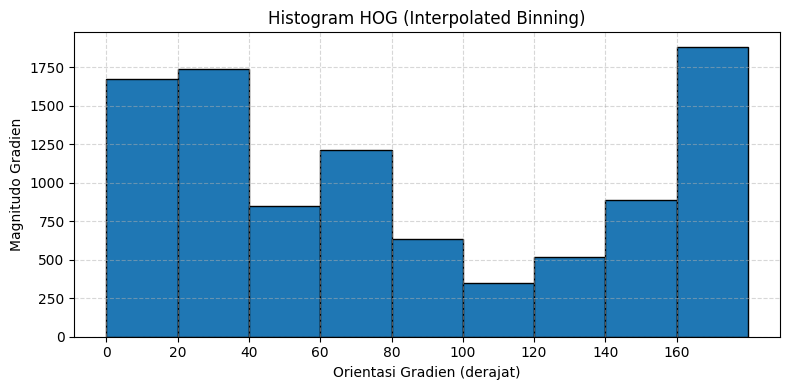

In [ ]:
# Cell kiri atas

import numpy as np
import matplotlib.pyplot as plt

# Data magnitude dan direction (arah sudut dalam derajat)
mag = np.array([
    [166.86, 106.32, 112.79, 171.45, 102.0, 106.68, 102.62, 193.38],
    [157.31, 127.58, 231.37, 207.71, 195.73, 174.13,  51.24,  63.07],
    [ 93.34, 119.64, 188.6,  164.98, 224.52, 233.83, 120.44, 122.59],
    [197.21, 130.21, 156.11, 112.18, 159.53, 262.07,  44.27,  24.04],
    [ 30.59, 259.26, 342.38, 233.85, 251.11, 256.03,  18.97,  56.14],
    [111.0, 281.4, 207.63, 103.24, 335.26, 206.89,  99.01,  93.68],
    [ 51.88, 284.31, 256.22, 121.8, 278.95, 203.96,  87.73,  35.61],
    [ 10.3, 151.42, 226.5,   73.88, 185.99, 202.41,  23.02,  44.72]
])

dir = np.array([
    [-115.18, -106.39, -165.1,  -163.04,  -28.07,   6.46, 105.26,  79.27],
    [-112.82,  -76.4,  -130.09, -128.75,   -7.63,  24.06, 107.02,  -2.73],
    [  45.0,  102.06,  143.19,  120.61,   18.43,  14.87, 119.33,  61.76],
    [  34.25, 126.25,  154.58,  168.69,    4.67,   1.31, 161.57, -73.07],
    [  11.31, -128.11, -122.11, -102.85,  -19.3,   -0.9, 161.57, 175.91],
    [ 169.09, -174.29, -159.12,   3.89,   17.35,  13.7, -135.82, -106.11],
    [-152.45, 158.76,  143.89,   29.51,  -17.53, -41.82, -136.85, -128.16],
    [ -60.95, 167.8,   150.95,  140.49,  -19.8,  -17.54,  -34.38, 116.57]
])

def compute_hog_cell_interpolated(direction, magnitude, bin_size=20):
    # Ubah semua sudut ke rentang [0, 180)
    direction = np.mod(direction, 180)

    bins = np.arange(0, 181, bin_size)  # contoh: [0, 20, ..., 180]
    histogram = np.zeros(len(bins) - 1)

    for i in range(direction.shape[0]):
        for j in range(direction.shape[1]):
            angle = direction[i, j]
            mag = magnitude[i, j]

            # Cari dua bin terdekat
            lower_bin = int(angle // bin_size)
            upper_bin = (lower_bin + 1) % len(histogram)

            lower_angle = bins[lower_bin]
            upper_angle = bins[upper_bin] if upper_bin > lower_bin else 180

            # Interpolasi linier
            weight_upper = (angle - lower_angle) / bin_size
            weight_lower = 1 - weight_upper

            histogram[lower_bin] += mag * weight_lower
            histogram[upper_bin] += mag * weight_upper

    return bins[:-1], histogram

# Hitung histogram HOG dengan interpolasi
bins, histogram = compute_hog_cell_interpolated(dir, mag)

# Plot histogram HOG
plt.figure(figsize=(8, 4))
plt.bar(bins, histogram, width=20, align='edge', edgecolor='black')
plt.xlabel('Orientasi Gradien (derajat)')
plt.ylabel('Magnitudo Gradien')
plt.title('Histogram HOG (Interpolated Binning)')
plt.xticks(bins)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


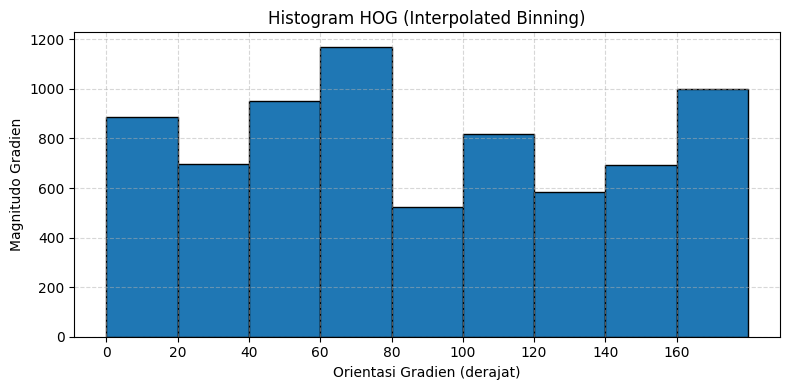

In [1]:
# Cell kanan atas

import numpy as np
import matplotlib.pyplot as plt

# Data magnitude dan direction (arah sudut dalam derajat)
mag = np.array([
    [163.17, 240.87, 65.19, 254.33, 121.75, 229.17, 233.65, 69.07],
    [55.03, 280.07, 58.82, 263.55, 31.05, 44.94, 92.20, 139.29],
    [56.30, 142.86, 194.83, 210.89, 29.83, 186.94, 193.49, 136.06],
    [100.32, 10.30, 51.22, 19.65, 119.55, 122.48, 82.97, 243.32],
    [108.23, 67.08, 45.34, 104.31, 17.49, 180.36, 223.77, 172.63],
    [81.44, 53.24, 72.24, 69.01, 79.65, 19.70, 60.17, 105.99],
    [85.88, 72.24, 82.07, 136.06, 67.60, 78.29, 29.83, 192.77],
    [44.38, 81.25, 149.57, 84.12, 161.62, 97.59, 77.47, 180.85],
])

dir = np.array([
    [108.21, 144.46, -20.66, -9.28, 137.66, 110.97, 51.95, 92.49],
    [70.91, 168.05, 125.31, -3.70, -14.93, 147.72, -114.34, -86.30],
    [-146.59, 166.64, 95.30, 47.31, -129.56, -120.54, -119.74, -24.30],
    [-175.43, 150.95, 38.66, 14.74, -162.47, -171.08, 74.62, 38.66],
    [141.75, 100.30, -131.42, -94.40, 120.96, 106.43, 67.68, 46.88],
    [155.32, 174.61, 158.05, 89.17, 28.50, 66.04, 15.42, -116.32],
    [-152.24, -158.05, 46.97, 91.68, 119.22, 28.20, 129.56, -157.43],
    [165.65, 166.48, 4.99, 61.61, 130.99, 45.83, 156.41, 128.26],
])

def compute_hog_cell_interpolated(direction, magnitude, bin_size=20):
    # Ubah semua sudut ke rentang [0, 180)
    direction = np.mod(direction, 180)

    bins = np.arange(0, 181, bin_size)  # contoh: [0, 20, ..., 180]
    histogram = np.zeros(len(bins) - 1)

    for i in range(direction.shape[0]):
        for j in range(direction.shape[1]):
            angle = direction[i, j]
            mag = magnitude[i, j]

            # Cari dua bin terdekat
            lower_bin = int(angle // bin_size)
            upper_bin = (lower_bin + 1) % len(histogram)

            lower_angle = bins[lower_bin]
            upper_angle = bins[upper_bin] if upper_bin > lower_bin else 180

            # Interpolasi linier
            weight_upper = (angle - lower_angle) / bin_size
            weight_lower = 1 - weight_upper

            histogram[lower_bin] += mag * weight_lower
            histogram[upper_bin] += mag * weight_upper

    return bins[:-1], histogram

# Hitung histogram HOG dengan interpolasi
bins, histogram = compute_hog_cell_interpolated(dir, mag)

# Plot histogram HOG
plt.figure(figsize=(8, 4))
plt.bar(bins, histogram, width=20, align='edge', edgecolor='black')
plt.xlabel('Orientasi Gradien (derajat)')
plt.ylabel('Magnitudo Gradien')
plt.title('Histogram HOG (Interpolated Binning)')
plt.xticks(bins)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


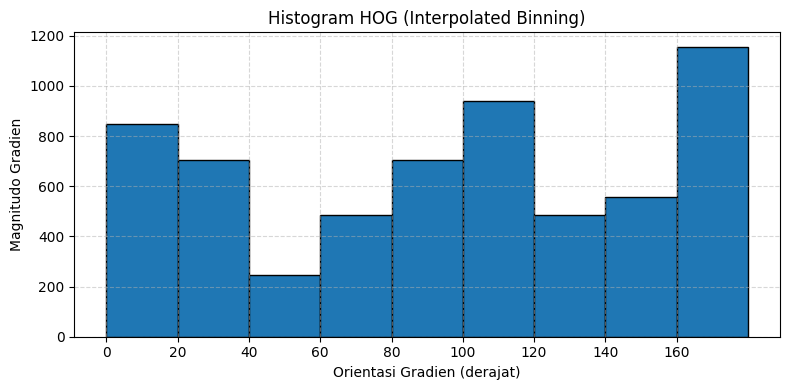

In [2]:
# Cell kanan bawah

import numpy as np
import matplotlib.pyplot as plt

# Data magnitude dan direction (arah sudut dalam derajat)
mag = np.array([
    [103.04, 95.71, 24.04, 117.65, 131.31, 180.43, 74.32, 153.84],
    [193.02, 200.57, 151.40, 55.08, 30.59, 80.81, 108.17, 247.78],
    [287.68, 46.17, 198.88, 60.02, 33.94, 86.53, 50.99, 192.34],
    [171.54, 169.85, 103.32, 30.89, 30.59, 70.33, 51.48, 102.31],
    [62.10, 39.12, 82.76, 87.28, 54.20, 62.80, 60.13, 80.05],
    [14.76, 41.11, 10.77, 62.10, 51.87, 34.06, 105.65, 54.00],
    [62.29, 54.92, 107.20, 56.94, 113.15, 128.14, 200.88, 24.70],
    [42.54, 80.62, 82.76, 85.15, 139.81, 116.25, 214.90, 72.80],
])

dir = np.array([
    [91.67, 10.84, -163.07, 160.64, 93.93, 66.13, 113.81, -116.23],
    [-169.85, -80.82, -53.05, 176.88, 11.31, 12.14, 123.69, 152.61],
    [-165.09, -107.65, -21.53, -100.56, -45.00, -33.69, -64.44, 166.47],
    [150.30, 100.52, 42.65, -29.05, -78.69, -29.85, -29.05, -175.52],
    [165.07, 122.47, 78.15, 85.40, 142.50, -9.16, -3.81, 102.99],
    [-118.30, 94.18, -111.80, -104.93, -146.00, -49.76, -17.06, 0.00],
    [42.40, 79.51, 171.42, -120.62, -116.79, -87.32, -12.65, -31.76],
    [-66.45, -82.87, -168.15, 102.89, 127.44, 81.59, 14.55, -142.82],
])

def compute_hog_cell_interpolated(direction, magnitude, bin_size=20):
    # Ubah semua sudut ke rentang [0, 180)
    direction = np.mod(direction, 180)

    bins = np.arange(0, 181, bin_size)  # contoh: [0, 20, ..., 180]
    histogram = np.zeros(len(bins) - 1)

    for i in range(direction.shape[0]):
        for j in range(direction.shape[1]):
            angle = direction[i, j]
            mag = magnitude[i, j]

            # Cari dua bin terdekat
            lower_bin = int(angle // bin_size)
            upper_bin = (lower_bin + 1) % len(histogram)

            lower_angle = bins[lower_bin]
            upper_angle = bins[upper_bin] if upper_bin > lower_bin else 180

            # Interpolasi linier
            weight_upper = (angle - lower_angle) / bin_size
            weight_lower = 1 - weight_upper

            histogram[lower_bin] += mag * weight_lower
            histogram[upper_bin] += mag * weight_upper

    return bins[:-1], histogram

# Hitung histogram HOG dengan interpolasi
bins, histogram = compute_hog_cell_interpolated(dir, mag)

# Plot histogram HOG
plt.figure(figsize=(8, 4))
plt.bar(bins, histogram, width=20, align='edge', edgecolor='black')
plt.xlabel('Orientasi Gradien (derajat)')
plt.ylabel('Magnitudo Gradien')
plt.title('Histogram HOG (Interpolated Binning)')
plt.xticks(bins)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


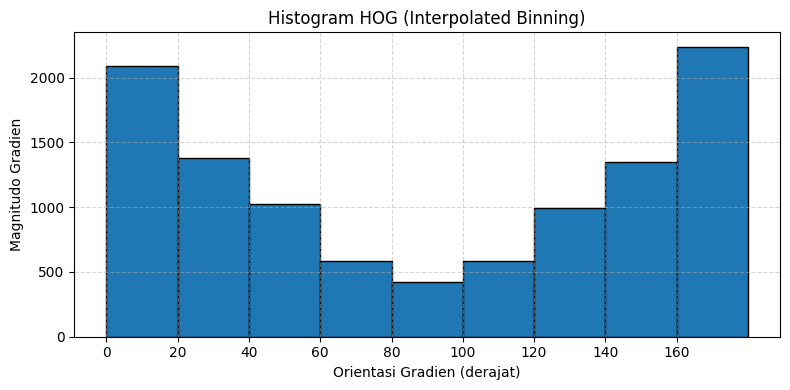

In [3]:
# Cell kiri bawah

import numpy as np
import matplotlib.pyplot as plt

# Data magnitude dan direction (arah sudut dalam derajat)
mag = np.array([
    [149.03, 172.24, 110.21, 185.07, 56.14, 247.02, 153.84, 315.39],
    [53.85, 186.68, 99.41, 138.06, 112.92, 286.72, 69.12, 364.66],
    [117.05, 81.01, 197.87, 40.25, 34.53, 276.13, 68.54, 398.42],
    [64.76, 108.98, 49.50, 192.77, 127.95, 280.37, 237.76, 380.68],
    [118.90, 99.41, 172.68, 96.18, 258.28, 177.59, 211.08, 373.46],
    [92.62, 104.96, 77.16, 299.14, 161.55, 191.44, 116.18, 305.94],
    [102.62, 76.90, 58.82, 294.03, 153.39, 123.04, 156.42, 339.25],
    [71.22, 89.31, 87.46, 208.17, 114.02, 110.14, 219.97, 246.13],
])

dir = np.array([
    [1.15, -12.75, -143.86, -141.58, -85.91, -179.30, -26.23, -15.45],
    [121.33, -57.25, -84.81, 141.47, 67.07, 168.53, 14.24, 3.46],
    [-123.15, -118.78, -38.43, -63.43, 79.99, 168.93, -156.80, -23.99],
    [13.39, 137.23, -45.00, -62.50, -58.42, -165.96, -147.71, -21.58],
    [71.87, 95.19, 137.35, -135.84, -59.26, -152.14, 146.99, 22.51],
    [-142.02, -59.04, 176.28, 178.28, -74.93, -77.63, -131.51, -11.31],
    [-127.87, -12.77, -125.31, -179.22, 79.86, 91.40, -149.66, -30.27],
    [51.84, 55.95, 157.83, 171.71, 21.61, 147.61, 145.37, 24.48],
])

def compute_hog_cell_interpolated(direction, magnitude, bin_size=20):
    # Ubah semua sudut ke rentang [0, 180)
    direction = np.mod(direction, 180)

    bins = np.arange(0, 181, bin_size)  # contoh: [0, 20, ..., 180]
    histogram = np.zeros(len(bins) - 1)

    for i in range(direction.shape[0]):
        for j in range(direction.shape[1]):
            angle = direction[i, j]
            mag = magnitude[i, j]

            # Cari dua bin terdekat
            lower_bin = int(angle // bin_size)
            upper_bin = (lower_bin + 1) % len(histogram)

            lower_angle = bins[lower_bin]
            upper_angle = bins[upper_bin] if upper_bin > lower_bin else 180

            # Interpolasi linier
            weight_upper = (angle - lower_angle) / bin_size
            weight_lower = 1 - weight_upper

            histogram[lower_bin] += mag * weight_lower
            histogram[upper_bin] += mag * weight_upper

    return bins[:-1], histogram

# Hitung histogram HOG dengan interpolasi
bins, histogram = compute_hog_cell_interpolated(dir, mag)

# Plot histogram HOG
plt.figure(figsize=(8, 4))
plt.bar(bins, histogram, width=20, align='edge', edgecolor='black')
plt.xlabel('Orientasi Gradien (derajat)')
plt.ylabel('Magnitudo Gradien')
plt.title('Histogram HOG (Interpolated Binning)')
plt.xticks(bins)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


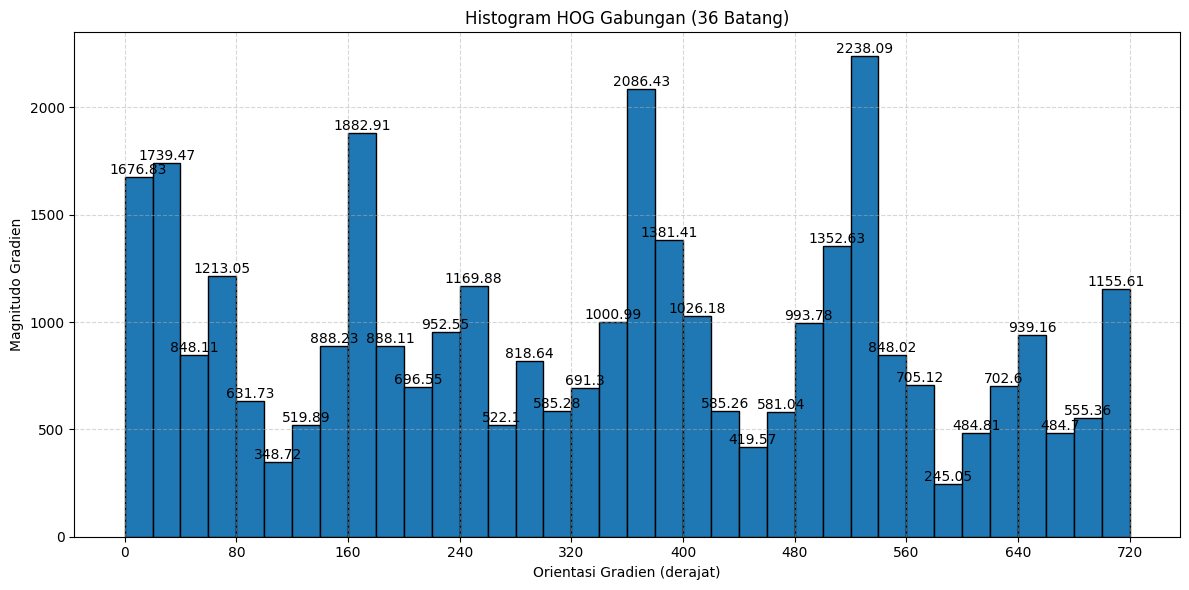

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Data magnitude dan direction untuk keempat sel
mag_data = [
    np.array([
        [166.86, 106.32, 112.79, 171.45, 102.0, 106.68, 102.62, 193.38],
        [157.31, 127.58, 231.37, 207.71, 195.73, 174.13,  51.24,  63.07],
        [ 93.34, 119.64, 188.6,  164.98, 224.52, 233.83, 120.44, 122.59],
        [197.21, 130.21, 156.11, 112.18, 159.53, 262.07,  44.27,  24.04],
        [ 30.59, 259.26, 342.38, 233.85, 251.11, 256.03,  18.97,  56.14],
        [111.0, 281.4, 207.63, 103.24, 335.26, 206.89,  99.01,  93.68],
        [ 51.88, 284.31, 256.22, 121.8, 278.95, 203.96,  87.73,  35.61],
        [ 10.3, 151.42, 226.5,   73.88, 185.99, 202.41,  23.02,  44.72]
    ]),
    np.array([
        [163.17, 240.87, 65.19, 254.33, 121.75, 229.17, 233.65, 69.07],
        [55.03, 280.07, 58.82, 263.55, 31.05, 44.94, 92.20, 139.29],
        [56.30, 142.86, 194.83, 210.89, 29.83, 186.94, 193.49, 136.06],
        [100.32, 10.30, 51.22, 19.65, 119.55, 122.48, 82.97, 243.32],
        [108.23, 67.08, 45.34, 104.31, 17.49, 180.36, 223.77, 172.63],
        [81.44, 53.24, 72.24, 69.01, 79.65, 19.70, 60.17, 105.99],
        [85.88, 72.24, 82.07, 136.06, 67.60, 78.29, 29.83, 192.77],
        [44.38, 81.25, 149.57, 84.12, 161.62, 97.59, 77.47, 180.85],
    ]),
    np.array([
        [149.03, 172.24, 110.21, 185.07, 56.14, 247.02, 153.84, 315.39],
        [53.85, 186.68, 99.41, 138.06, 112.92, 286.72, 69.12, 364.66],
        [117.05, 81.01, 197.87, 40.25, 34.53, 276.13, 68.54, 398.42],
        [64.76, 108.98, 49.50, 192.77, 127.95, 280.37, 237.76, 380.68],
        [118.90, 99.41, 172.68, 96.18, 258.28, 177.59, 211.08, 373.46],
        [92.62, 104.96, 77.16, 299.14, 161.55, 191.44, 116.18, 305.94],
        [102.62, 76.90, 58.82, 294.03, 153.39, 123.04, 156.42, 339.25],
        [71.22, 89.31, 87.46, 208.17, 114.02, 110.14, 219.97, 246.13],
    ]),
    np.array([
        [103.04, 95.71, 24.04, 117.65, 131.31, 180.43, 74.32, 153.84],
        [193.02, 200.57, 151.40, 55.08, 30.59, 80.81, 108.17, 247.78],
        [287.68, 46.17, 198.88, 60.02, 33.94, 86.53, 50.99, 192.34],
        [171.54, 169.85, 103.32, 30.89, 30.59, 70.33, 51.48, 102.31],
        [62.10, 39.12, 82.76, 87.28, 54.20, 62.80, 60.13, 80.05],
        [14.76, 41.11, 10.77, 62.10, 51.87, 34.06, 105.65, 54.00],
        [62.29, 54.92, 107.20, 56.94, 113.15, 128.14, 200.88, 24.70],
        [42.54, 80.62, 82.76, 85.15, 139.81, 116.25, 214.90, 72.80],
    ])
]

def compute_hog_cell_interpolated(direction, magnitude, bin_size=20):
    # Ubah semua sudut ke rentang [0, 180)
    direction = np.mod(direction, 180)

    bins = np.arange(0, 181, bin_size)  # contoh: [0, 20, ..., 180]
    histogram = np.zeros(len(bins) - 1)

    for i in range(direction.shape[0]):
        for j in range(direction.shape[1]):
            angle = direction[i, j]
            mag = magnitude[i, j]

            # Cari dua bin terdekat
            lower_bin = int(angle // bin_size)
            upper_bin = (lower_bin + 1) % len(histogram)

            lower_angle = bins[lower_bin]
            upper_angle = bins[upper_bin] if upper_bin > lower_bin else 180

            # Interpolasi linier
            weight_upper = (angle - lower_angle) / bin_size
            weight_lower = 1 - weight_upper

            histogram[lower_bin] += mag * weight_lower
            histogram[upper_bin] += mag * weight_upper

    return bins[:-1], histogram

# Hitung histogram HOG untuk setiap sel
histograms = []
for mag, dir in zip(mag_data, dir_data):
    _, histogram = compute_hog_cell_interpolated(dir, mag)
    histograms.append(histogram)

# Gabungkan histogram menjadi satu histogram dengan 36 batang (4 sel x 9 bin)
combined_histogram = np.concatenate(histograms)

# Buat bins untuk histogram gabungan (36 batang)
combined_bins = np.arange(0, 36 * 20 + 1, 20)  # 0, 20, ..., 720 (37 edges for 36 bins)

# Plot histogram gabungan
plt.figure(figsize=(12, 6))
bars = plt.bar(combined_bins[:-1], combined_histogram, width=20, align='edge', edgecolor='black')

# Tambahkan nilai di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.xlabel('Orientasi Gradien (derajat)')
plt.ylabel('Magnitudo Gradien')
plt.title('Histogram HOG Gabungan (36 Batang)')
plt.xticks(np.arange(0, 36 * 20 + 1, 80))  # Set ticks untuk setiap 80 derajat
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [5]:
import cv2  # Import OpenCV untuk pemrosesan citra dan video
import imutils  # Import imutils untuk fungsi utilitas tambahan seperti resize gambar


hog = cv2.HOGDescriptor()  
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())  

img = cv2.imread("manusia.jpg")  

img = imutils.resize(img, width=min(400, img.shape[0]))  

cv2.imshow("test", img)
cv2.waitKey(0)
cv2.destroyAllWindows
# (regions, _) = hog.detectMultiScale(img, winStride=(4,4), padding=(4,4), scale=1.05)

# for (x, y, w, h) in regions:
#     cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)
#     cv2.imshow("image", img)
#     cv2.waitKey() 


<function destroyAllWindows>

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar asli
image = cv2.imread("manusia.jpg")
image = cv2.resize(image, (128, 256))  # Ukuran disarankan HOG default

# Konversi ke grayscale (HOG biasanya pakai grayscale)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Inisialisasi HOG
hog = cv2.HOGDescriptor()

# Hitung fitur HOG (bukan hanya deteksi, ini hasil vektor fitur)
hog_features = hog.compute(gray)

# Fungsi bantu untuk memvisualisasikan fitur HOG
def visualize_hog(gray_image):
    winSize = (64, 128)
    blockSize = (16, 16)
    blockStride = (8, 8)
    cellSize = (8, 8)
    nbins = 9

    hog_vis = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)
    h = hog_vis.compute(gray_image)

    # Visualisasi hanya estimasi (karena OpenCV tidak menyimpan arah gradien mentah)
    # Maka kita pakai matplotlib untuk menampilkan grayscale + vector HOG saja
    plt.figure(figsize=(6, 6))
    plt.title("Gambar Grayscale")
    plt.imshow(gray_image, cmap='gray')
    plt.axis('off')
    plt.show()

# Tampilkan hasil visualisasi HOG
visualize_hog(gray)


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


In [12]:
import cv2

img = cv2.imread('Citra_Asli.JPG')
img = cv2.resize(img, (5472, 3648))
img = cv2.imwrite('resizefix.jpg', img)

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


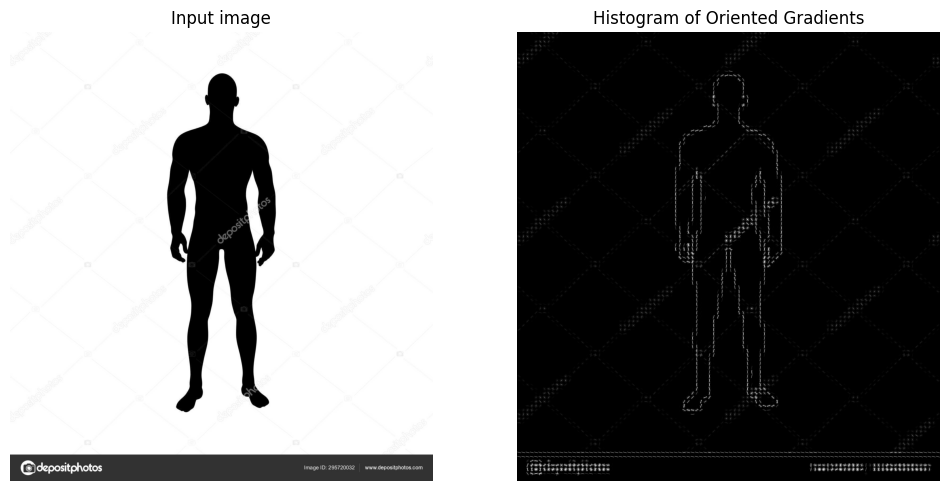

In [7]:
import matplotlib.pyplot as plt  # Import modul untuk menampilkan gambar

from skimage.feature import hog  # Import fungsi HOG (Histogram of Oriented Gradients)
from skimage import exposure, data  # Import modul exposure untuk penyesuaian intensitas dan data untuk contoh gambar
import cv2

image = cv2.imread("manusia.jpg")  # Memuat gambar contoh 'astronaut' dari skimage

# Menghitung fitur HOG dan menghasilkan visualisasi HOG
# orientations=8: jumlah arah gradien
# pixels_per_cell=(16,16): ukuran tiap sel piksel
# cells_per_block=(1,1): ukuran blok yang terdiri dari sel
# visualize=True: hasilkan juga gambar visualisasi HOG
# channel_axis=-1: gambar berwarna dengan channel terakhir adalah warna
fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True, channel_axis=-1)

# Membuat 2 subplot berdampingan untuk menampilkan gambar asli dan hasil HOG
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax1.axis('off')  # Sembunyikan sumbu pada subplot pertama
ax1.imshow(image, cmap=plt.cm.gray)  # Tampilkan gambar asli
ax1.set_title('Input image')  # Beri judul

# Sesuaikan intensitas gambar HOG agar lebih jelas ditampilkan
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')  # Sembunyikan sumbu pada subplot kedua
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)  # Tampilkan hasil visualisasi HOG yang sudah disesuaikan
ax2.set_title('Histogram of Oriented Gradients')  # Beri judul

plt.show()  # Tampilkan semua subplot
